In [12]:
import pandas as pd
import math
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import statistics

import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("cabai merah.csv", sep=";")
df

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),58495,51150
1,Apr 2017 (II),59712,50700
2,Apr 2017 (III),51705,50850
3,Apr 2017 (IV),53092,51400
4,May 2017 (V),53954,56150
...,...,...,...
302,Jan 2023 (IV),50138,45850
303,Feb 2023 (I),52962,54150
304,Feb 2023 (II),54819,58300
305,Feb 2023 (III),58716,59000


In [14]:
df_copy = df.copy()

last = len(df_copy.index)
nPred = 15

# df_copy = df_copy.drop(index=df.index[last-nPred-1:last-1])

# 100 data terakhir
# df_copy = df_copy.drop(index=df.index[0:last-100])

# df_copy.reset_index(inplace=True, drop=True)
# df_copy

In [15]:
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),58495,51150
1,Apr 2017 (II),59712,50700
2,Apr 2017 (III),51705,50850
3,Apr 2017 (IV),53092,51400
4,May 2017 (V),53954,56150
...,...,...,...
302,Jan 2023 (IV),50138,45850
303,Feb 2023 (I),52962,54150
304,Feb 2023 (II),54819,58300
305,Feb 2023 (III),58716,59000


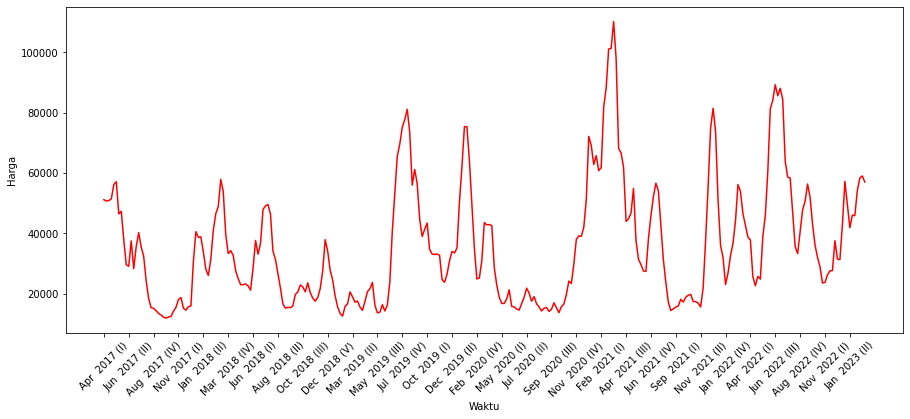

In [16]:
plt.figure(figsize=(15,6))
plt.plot(df_copy['Komoditas (Rp)'], df['Jawa Timur'], color='red')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df_copy.index)-1,10))
plt.show()

In [17]:
sd = statistics.pstdev(df_copy['Jawa Timur'].to_numpy())
meanS = statistics.mean(df_copy['Jawa Timur'].to_numpy())
print("Koefisien Variasi = ",sd/meanS*100,"%")

Koefisien Variasi =  55.43707512072425 %


In [18]:
Dt = df_copy['Jawa Timur']
Dmin = Dt.min()
Dmax = Dt.max()
N = Dt.count()
Z1 = 950
Z2 = 400

print(Dmin, Dmax, N)

11950 110100 307


In [19]:
R = Dmax+Z2 - (Dmin-Z1)
print(R)

99500


In [20]:
dif = []
df2 = df_copy

for i in range (N-1):
    dt = df['Jawa Timur'][i]
    dt2 = df['Jawa Timur'][i+1]
    ab = round(abs(dt2-dt),2)
    df2.at[i, '|Dt+1 - Dt|'] = ab

df2.at[N-1, '|Dt+1 - Dt|'] = 0

In [21]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|
0,Apr 2017 (I),58495,51150,450.0
1,Apr 2017 (II),59712,50700,150.0
2,Apr 2017 (III),51705,50850,550.0
3,Apr 2017 (IV),53092,51400,4750.0
4,May 2017 (V),53954,56150,950.0
...,...,...,...,...
302,Jan 2023 (IV),50138,45850,8300.0
303,Feb 2023 (I),52962,54150,4150.0
304,Feb 2023 (II),54819,58300,700.0
305,Feb 2023 (III),58716,59000,2000.0


In [22]:
mean = (sum(df2['|Dt+1 - Dt|']))/(N-1)
print(mean)

4878.59477124183


In [23]:
K = mean/2
if(K<1):
    K = round(K,1)
else:
    K = math.ceil(K)

print(K)

2440


In [24]:
n = math.ceil(R/K)
print(n)

41


In [25]:
himpFuzzy = pd.DataFrame()
ui = []
batasBawah = []
batasAtas = []
Ai = []
ui.append('u1')
Ai.append('A1')
batasBawah.append(Dmin-Z1)
batasAtas.append(batasBawah[0] + K)

for i in range(1, n):
    ui.append('u'+str(i+1))
    Ai.append('A'+str(i+1))
    batasBawah.append(batasAtas[i-1])
    batasAtas.append(batasBawah[i] + K)

himpFuzzy['ui'] = ui
himpFuzzy['Ai'] = Ai
himpFuzzy['batas bawah'] = batasBawah
himpFuzzy['batas atas'] = batasAtas

In [26]:
himpFuzzy['mi'] = (himpFuzzy['batas bawah'] + himpFuzzy['batas atas'])/2

In [27]:
himpFuzzy

,ui,Ai,batas bawah,batas atas,mi
0,u1,A1,11000,13440,12220.0
1,u2,A2,13440,15880,14660.0
2,u3,A3,15880,18320,17100.0
3,u4,A4,18320,20760,19540.0
4,u5,A5,20760,23200,21980.0
5,u6,A6,23200,25640,24420.0
6,u7,A7,25640,28080,26860.0
7,u8,A8,28080,30520,29300.0
8,u9,A9,30520,32960,31740.0
9,u10,A10,32960,35400,34180.0


In [28]:
# FLR dan FLRG
data = df2['Jawa Timur']

hasilFuzzy = []
for i in data:
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= i 
    cond2 = copyHimp['batas atas'] >= i 
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    hasilFuzzy.append(fuzzyfikasi)

df2['fuzzyfikasi'] = hasilFuzzy

In [29]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi
0,Apr 2017 (I),58495,51150,450.0,A17
1,Apr 2017 (II),59712,50700,150.0,A17
2,Apr 2017 (III),51705,50850,550.0,A17
3,Apr 2017 (IV),53092,51400,4750.0,A17
4,May 2017 (V),53954,56150,950.0,A19
...,...,...,...,...,...
302,Jan 2023 (IV),50138,45850,8300.0,A15
303,Feb 2023 (I),52962,54150,4150.0,A18
304,Feb 2023 (II),54819,58300,700.0,A20
305,Feb 2023 (III),58716,59000,2000.0,A20


In [30]:
nextState = []
for k in range(0, len(df2.index)-1):
    neSt = df2['fuzzyfikasi'].iloc[k+1]
    nextState.append(neSt)

df2['next state'] = pd.Series(nextState)

In [31]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state
0,Apr 2017 (I),58495,51150,450.0,A17,A17
1,Apr 2017 (II),59712,50700,150.0,A17,A17
2,Apr 2017 (III),51705,50850,550.0,A17,A17
3,Apr 2017 (IV),53092,51400,4750.0,A17,A19
4,May 2017 (V),53954,56150,950.0,A19,A19
...,...,...,...,...,...,...
302,Jan 2023 (IV),50138,45850,8300.0,A15,A18
303,Feb 2023 (I),52962,54150,4150.0,A18,A20
304,Feb 2023 (II),54819,58300,700.0,A20,A20
305,Feb 2023 (III),58716,59000,2000.0,A20,A19


In [32]:
# FLRG
dfFLRG = pd.DataFrame()
dfFLRG['Ai'] = himpFuzzy['Ai']
dfFLRG['FLRG'] = ''

# ambil df2 kecuali baris terakhir karena next statenya kosong
df3 = df2[:-1]

for f in range(len(dfFLRG.index)):
    searchAi = 'A'+str(f+1)
    
    new = df3[df3['fuzzyfikasi'].isin([searchAi])]
    group = new['next state']
    group = group.to_numpy()
    
    if len(group) > 0 :
        dfFLRG['FLRG'][f] = group

In [33]:
dfFLRG

,Ai,FLRG
0,A1,"[A1, A1, A1, A1, A2, A2]"
1,A2,"[A2, A2, A2, A1, A2, A3, A2, A2, A3, A2, A2, A..."
2,A3,"[A4, A9, A2, A4, A4, A4, A3, A2, A4, A2, A2, A..."
3,A4,"[A2, A2, A4, A5, A6, A4, A3, A5, A2, A4, A3, A..."
4,A5,"[A5, A6, A5, A8, A3, A5, A4, A7, A6, A4, A2, A..."
5,A6,"[A4, A5, A5, A4, A4, A3, A13, A6, A7, A6, A9, ..."
6,A7,"[A9, A6, A5, A12, A6, A9, A7, A12, A9, A5, A6,..."
7,A8,"[A8, A11, A11, A7, A11, A5, A12, A7, A6]"
8,A9,"[A6, A13, A13, A7, A7, A6, A10, A14, A8, A6, A..."
9,A10,"[A8, A10, A9, A11, A9, A7, A10, A10, A10, A9, ..."


In [34]:
# hasil fuzzyfikasi
dfFLRG['defuzzyfikasi'] = ''

for g in range(len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[g]
    flrg = dfFLRG['FLRG'].loc[g]
    hasil = 0

    if (len(flrg) == 0):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == ai]['mi']
        hasil = fuzzyfikasi.values[0]
    
    elif (len(flrg) == 1):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == flrg[0]]['mi']
        hasil = fuzzyfikasi.values[0]
        
    else:
        lenFlrg = len(flrg)
        for h in range(len(flrg)):
            mi = himpFuzzy[himpFuzzy['Ai'] == flrg[h]]['mi']
            bobot = (1/len(flrg)) * mi.values[0]
            hasil = hasil + bobot
            

    dfFLRG['defuzzyfikasi'][g] = hasil

In [35]:
dfFLRG

,Ai,FLRG,defuzzyfikasi
0,A1,"[A1, A1, A1, A1, A2, A2]",13033.333333
1,A2,"[A2, A2, A2, A1, A2, A3, A2, A2, A3, A2, A2, A...",15451.351351
2,A3,"[A4, A9, A2, A4, A4, A4, A3, A2, A4, A2, A2, A...",18184.444444
3,A4,"[A2, A2, A4, A5, A6, A4, A3, A5, A2, A4, A3, A...",19052.0
4,A5,"[A5, A6, A5, A8, A3, A5, A4, A7, A6, A4, A2, A...",23606.666667
5,A6,"[A4, A5, A5, A4, A4, A3, A13, A6, A7, A6, A9, ...",25281.176471
6,A7,"[A9, A6, A5, A12, A6, A9, A7, A12, A9, A5, A6,...",29125.714286
7,A8,"[A8, A11, A11, A7, A11, A5, A12, A7, A6]",30926.666667
8,A9,"[A6, A13, A13, A7, A7, A6, A10, A14, A8, A6, A...",32065.333333
9,A10,"[A8, A10, A9, A11, A9, A7, A10, A10, A10, A9, ...",34017.333333


In [36]:
df2['yt'] = ''

for y in range (len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[y]
    listAi = df2[df2['fuzzyfikasi'] == ai]
    yt = dfFLRG['defuzzyfikasi'][y]
    
    if len(listAi) > 0:
        idx = listAi.index
        for z in idx:
            df2.at[z+1,'yt'] = yt

In [37]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),58495.0,51150.0,450.0,A17,A17,
1,Apr 2017 (II),59712.0,50700.0,150.0,A17,A17,53700.0
2,Apr 2017 (III),51705.0,50850.0,550.0,A17,A17,53700.0
3,Apr 2017 (IV),53092.0,51400.0,4750.0,A17,A19,53700.0
4,May 2017 (V),53954.0,56150.0,950.0,A19,A19,53700.0
...,...,...,...,...,...,...,...
303,Feb 2023 (I),52962.0,54150.0,4150.0,A18,A20,46601.818182
304,Feb 2023 (II),54819.0,58300.0,700.0,A20,A20,48006.666667
305,Feb 2023 (III),58716.0,59000.0,2000.0,A20,A19,54676.0
306,Feb 2023 (IV),60141.0,57000.0,0.0,A19,NaN,54676.0


In [38]:
# MAPE
y_actual = df2['Jawa Timur'][1:-1].to_numpy()
y_predict = df2['yt'][1:-1].to_numpy()

# MAE
MAE = mean_absolute_error(y_actual, y_predict)
print("MAE = ",MAE)

# Root MSE squared=False
RMSE = mean_squared_error(y_actual, y_predict, squared=False)
print("RMSE = ",RMSE)

MAPE = mean_absolute_percentage_error(y_actual, y_predict)
print("MAPE = ",MAPE*100)

MAE =  4469.040003004247
RMSE =  6138.642342323997
MAPE =  13.094139237444727


In [39]:
lastIndex = len(df2.index)
dfPredictNext = df2

dfPredictNext.at[lastIndex-1, 'Komoditas (Rp)'] = 'Periode+1'
for n in range (nPred-1):
    # Add fuzzyfikai dr hasil predict
    nilaiYt = dfPredictNext['yt'][lastIndex-1+n]
    
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= nilaiYt
    cond2 = copyHimp['batas atas'] >= nilaiYt
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    dfPredictNext.at[lastIndex + n-1, 'fuzzyfikasi'] = fuzzyfikasi

    # add predict
    yt = dfFLRG['defuzzyfikasi'][dfFLRG['Ai'] == fuzzyfikasi]
    dfPredictNext.at[lastIndex+n, 'yt'] = yt.values[0]
    
    dfPredictNext.at[lastIndex+n, 'Komoditas (Rp)'] = "Prediksi+"+str(n+2)
    

In [40]:
dfPredictNext

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),58495.0,51150.0,450.0,A17,A17,
1,Apr 2017 (II),59712.0,50700.0,150.0,A17,A17,53700.0
2,Apr 2017 (III),51705.0,50850.0,550.0,A17,A17,53700.0
3,Apr 2017 (IV),53092.0,51400.0,4750.0,A17,A19,53700.0
4,May 2017 (V),53954.0,56150.0,950.0,A19,A19,53700.0
...,...,...,...,...,...,...,...
317,Prediksi+11,NaN,NaN,NaN,A15,NaN,46601.818182
318,Prediksi+12,NaN,NaN,NaN,A15,NaN,46601.818182
319,Prediksi+13,NaN,NaN,NaN,A15,NaN,46601.818182
320,Prediksi+14,NaN,NaN,NaN,A15,NaN,46601.818182


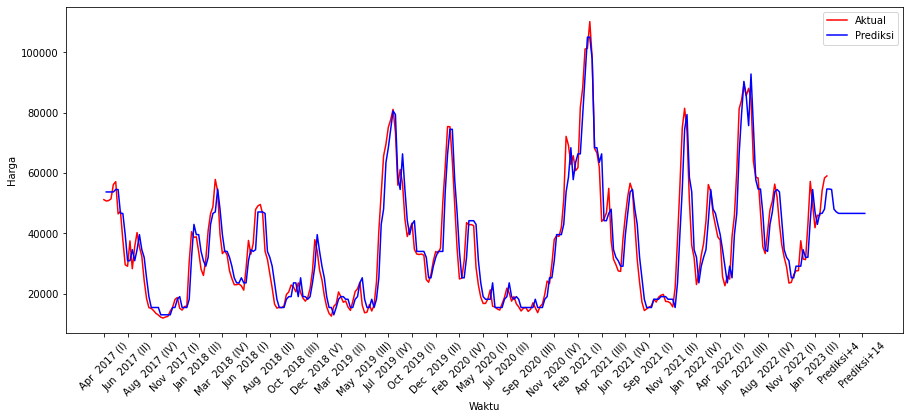

In [41]:
plt.figure(figsize=(15,6))
plt.plot(dfPredictNext['Komoditas (Rp)'][0:306], dfPredictNext['Jawa Timur'][0:306], color='red', label='Aktual')
plt.plot(dfPredictNext['Komoditas (Rp)'][1:len(dfPredictNext.index)], dfPredictNext['yt'][1:len(dfPredictNext.index)], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(dfPredictNext.index)-1,10))
plt.legend()
plt.show()

In [42]:
# df_result = df.copy()
# df_result['yt'] = df2['yt']
# df_result

In [43]:
# # MAPE pred
# y_actualpred = df_result['Jawa Timur'][last-nPred:len(df_result.index)].to_numpy()
# y_predictpred = df_result['yt'][last-nPred:len(df_result.index)].to_numpy()

# # MAPE
# MAPE2 = mean_absolute_percentage_error(y_actualpred, y_predictpred)
# # Root MSE squared=False
# RMSE2 = mean_squared_error(y_actualpred, y_predictpred, squared=False)
# # MAE
# MAE2 = mean_absolute_error(y_actualpred, y_predictpred)

# print("MAE = ",MAE2)
# print("RMSE = ",RMSE2)
# print("MAPE = ",MAPE2*100)

In [44]:
# # MAPE all
# y_actual2 = df_result['Jawa Timur'][1:len(df_result.index)].to_numpy()
# # print(y_actual2)
# y_predict2 = df_result['yt'][1:len(df_result.index)].to_numpy()
# # MAPE
# MAPE3 = mean_absolute_percentage_error(y_actual2, y_predict2)
# # Root MSE squared=False
# RMSE3 = mean_squared_error(y_actual2, y_predict2, squared=False)
# # MAE
# MAE3 = mean_absolute_error(y_actual2, y_predict2)
# print("MAE = ",MAE3)
# print("RMSE = ",RMSE3)
# print("MAPE = ",MAPE3*100)